Evaluation:

Epoch 1 - Loss: 0.2152 - Elapsed Time: 217.0 seconds - Epoch Time: 208.5 seconds

Epoch 2 - Loss: 0.1721 - Elapsed Time: 423.7 seconds - Epoch Time: 206.0 seconds

Epoch 3 - Loss: 0.1574 - Elapsed Time: 628.8 seconds - Epoch Time: 204.5 seconds

Epoch 4 - Loss: 0.1484 - Elapsed Time: 833.2 seconds - Epoch Time: 203.8 seconds

Epoch 5 - Loss: 0.1412 - Elapsed Time: 1037.5 seconds - Epoch Time: 203.8 seconds

Epoch 6 - Loss: 0.1373 - Elapsed Time: 1241.4 seconds - Epoch Time: 203.3 seconds

Epoch 7 - Loss: 0.1329 - Elapsed Time: 1448.7 seconds - Epoch Time: 206.8 seconds

Epoch 8 - Loss: 0.1296 - Elapsed Time: 1657.9 seconds - Epoch Time: 208.6 seconds

Epoch 9 - Loss: 0.1268 - Elapsed Time: 1864.5 seconds - Epoch Time: 206.0 seconds

Epoch 10 - Loss: 0.1249 - Elapsed Time: 2073.0 seconds - Epoch Time: 208.1 seconds

Epoch 11 - Loss: 0.1220 - Elapsed Time: 2283.9 seconds - Epoch Time: 210.3 seconds

Epoch 12 - Loss: 0.1213 - Elapsed Time: 2499.7 seconds - Epoch Time: 215.3 seconds

Epoch 13 - Loss: 0.1187 - Elapsed Time: 2718.1 seconds - Epoch Time: 217.6 seconds

Epoch 14 - Loss: 0.1180 - Elapsed Time: 2938.2 seconds - Epoch Time: 219.2 seconds

Epoch 15 - Loss: 0.1164 - Elapsed Time: 3155.6 seconds - Epoch Time: 216.5 seconds

Epoch 16 - Loss: 0.1144 - Elapsed Time: 3363.4 seconds - Epoch Time: 207.3 seconds

Epoch 17 - Loss: 0.1141 - Elapsed Time: 3570.1 seconds - Epoch Time: 206.2 seconds

Epoch 18 - Loss: 0.1121 - Elapsed Time: 3776.8 seconds - Epoch Time: 206.1 seconds

Epoch 19 - Loss: 0.1113 - Elapsed Time: 3984.0 seconds - Epoch Time: 206.7 seconds

Epoch 20 - Loss: 0.1106 - Elapsed Time: 4191.8 seconds - Epoch Time: 207.2 seconds

Epoch 21 - Loss: 0.1095 - Elapsed Time: 4399.7 seconds - Epoch Time: 207.5 seconds

Epoch 22 - Loss: 0.1089 - Elapsed Time: 4607.4 seconds - Epoch Time: 207.2 seconds

Epoch 23 - Loss: 0.1077 - Elapsed Time: 4815.9 seconds - Epoch Time: 208.0 seconds

Epoch 24 - Loss: 0.1070 - Elapsed Time: 5023.6 seconds - Epoch Time: 207.1 seconds

Epoch 25 - Loss: 0.1062 - Elapsed Time: 5230.7 seconds - Epoch Time: 206.5 seconds

Epoch 26 - Loss: 0.1061 - Elapsed Time: 5438.5 seconds - Epoch Time: 207.3 seconds

Epoch 27 - Loss: 0.1049 - Elapsed Time: 5644.5 seconds - Epoch Time: 205.5 seconds

Epoch 28 - Loss: 0.1043 - Elapsed Time: 5851.6 seconds - Epoch Time: 206.6 seconds

Epoch 29 - Loss: 0.1034 - Elapsed Time: 6061.1 seconds - Epoch Time: 208.9 seconds

Epoch 30 - Loss: 0.1035 - Elapsed Time: 6266.7 seconds - Epoch Time: 205.1 seconds

Epoch 31 - Loss: 0.1029 - Elapsed Time: 6471.6 seconds - Epoch Time: 204.4 seconds

Epoch 32 - Loss: 0.1022 - Elapsed Time: 6676.3 seconds - Epoch Time: 204.2 seconds

Epoch 33 - Loss: 0.1020 - Elapsed Time: 6883.7 seconds - Epoch Time: 206.8 seconds

Epoch 34 - Loss: 0.1011 - Elapsed Time: 7095.6 seconds - Epoch Time: 211.4 seconds

Epoch 35 - Loss: 0.1008 - Elapsed Time: 7306.3 seconds - Epoch Time: 210.2 seconds

Epoch 36 - Loss: 0.1002 - Elapsed Time: 7515.1 seconds - Epoch Time: 208.3 seconds

Epoch 37 - Loss: 0.0997 - Elapsed Time: 7719.8 seconds - Epoch Time: 204.1 seconds

Epoch 38 - Loss: 0.0995 - Elapsed Time: 7924.0 seconds - Epoch Time: 203.7 seconds

Epoch 39 - Loss: 0.0990 - Elapsed Time: 8128.0 seconds - Epoch Time: 203.5 seconds

Epoch 40 - Loss: 0.0983 - Elapsed Time: 8332.2 seconds - Epoch Time: 203.7 seconds

Epoch 41 - Loss: 0.0981 - Elapsed Time: 8538.3 seconds - Epoch Time: 205.6 seconds

Total Training Time approx. 2 hours 20 minutes
After 40 epochs, the loss is around 10%, what is a good sign.

The Reconstructed Images are very close to the original ones, but still somewhat blurry.

The sample photos were not selected carefully, which affected the quality of the face swap results. I randomly chose a man and a woman, and additionally, the woman was wearing glasses. We will take other sample on the next version.

Here are visual results from the training process:

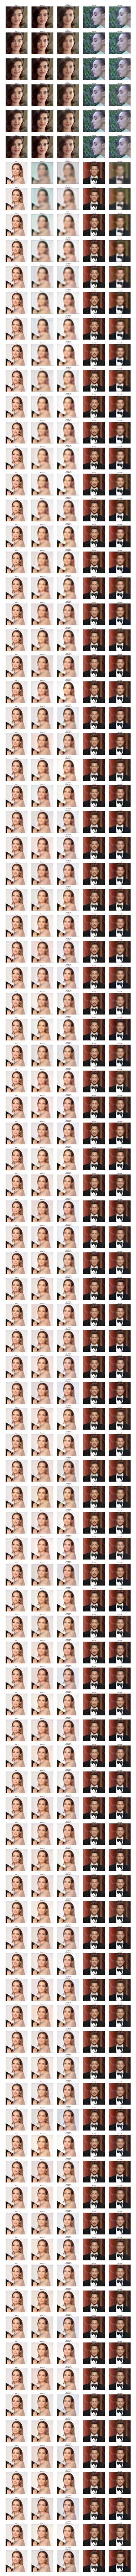

In [2]:
import os
from PIL import Image
import matplotlib.pyplot as plt

path = "./checkpoints/"

folders = []

for f in os.listdir(path):
    full_path = os.path.join(path, f)

    if os.path.isdir(full_path) and f.isdigit():
        folders.append(f)

folders.sort(key=lambda x: int(x))

images = []

for folder in folders:
    folder_path = os.path.join(path, folder)

    png_files = sorted(
        [f for f in os.listdir(folder_path) if f.lower().endswith(".png")]
    )

    for file in png_files:
        img_path = os.path.join(folder_path, file)
        img = Image.open(img_path)
        images.append(img)

if not images:
    print("No images found.")
    exit()

max_width = 2000
total_height = sum(img.height for img in images)

merged_image = Image.new("RGB", (max_width, total_height))

y_offset = 0
for img in images:
    merged_image.paste(img, (0, y_offset))
    y_offset += img.height

plt.figure(figsize=(40, 80))
plt.imshow(merged_image)
plt.axis("off")
plt.tight_layout()
plt.show()

Interpretation:

Before Epoch 20 Model was still learning the basic features of the faces, and the swapped results are not very convincing.

After Epoch 30 I can't see much improvement in the results, and the loss is not decreasing significantly, which indicates that the model is converging.

Now let's try swapping face with the trained model and see the results:

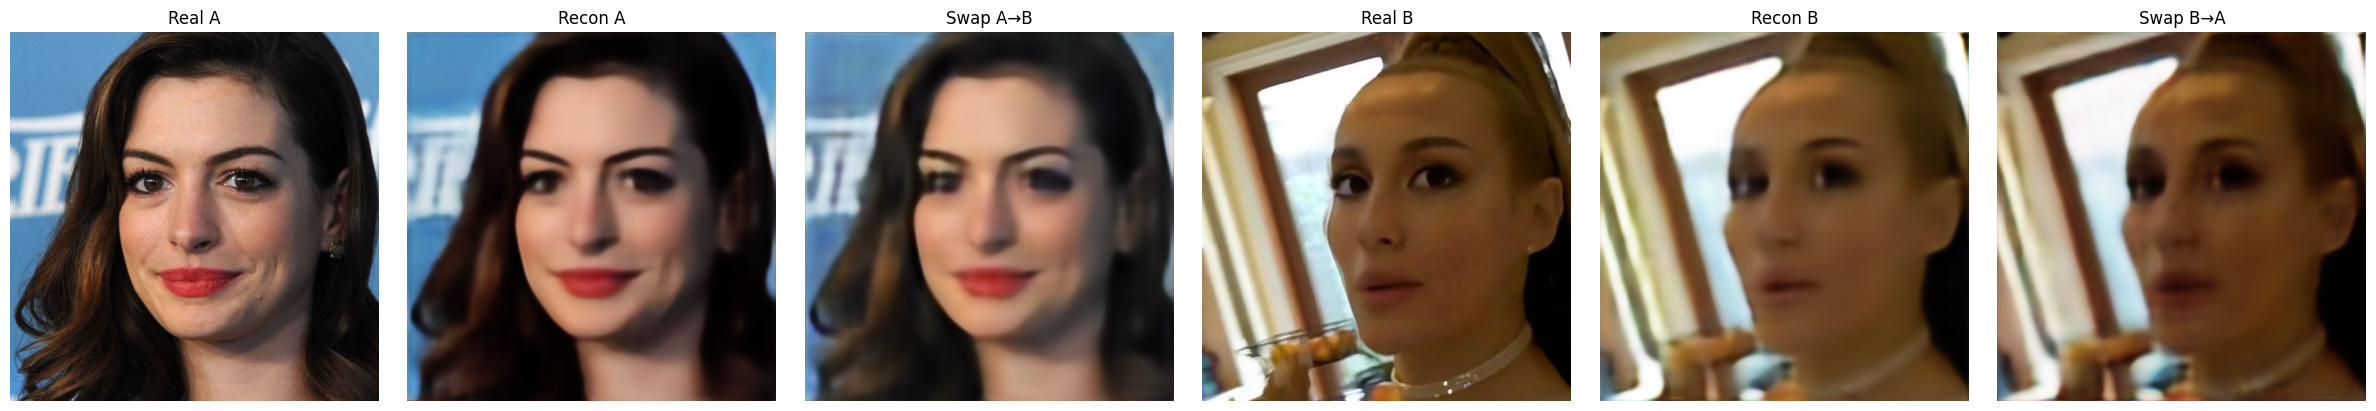

In [6]:
from torchvision import transforms
import torch
from train import Encoder, Decoder, denormalize

EPOCH = 8

def to_numpy(tensor):
    return denormalize(tensor.squeeze(0)).clamp(0, 1).permute(1, 2, 0).cpu().numpy()

def swap_faces(sample_a_path, sample_b_path):
    encoder = Encoder().to("cuda")
    decoder_a = Decoder().to("cuda")
    decoder_b = Decoder().to("cuda")

    encoder.load_state_dict(torch.load(f"checkpoints/{EPOCH}/encoder.pth",   map_location="cuda"))
    decoder_a.load_state_dict(torch.load(f"checkpoints/{EPOCH}/decoder_A.pth", map_location="cuda"))
    decoder_b.load_state_dict(torch.load(f"checkpoints/{EPOCH}/decoder_B.pth", map_location="cuda"))

    encoder.eval()
    decoder_a.eval()
    decoder_b.eval()

    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
    ])

    img_a = Image.open(sample_a_path).convert('RGB')
    img_b = Image.open(sample_b_path).convert('RGB')

    sample_a = transform(img_a).unsqueeze(0).to("cuda")
    sample_b = transform(img_b).unsqueeze(0).to("cuda")

    with torch.no_grad():
        latent_a = encoder(sample_a)
        latent_b = encoder(sample_b)

        recon_a  = decoder_a(latent_a)
        recon_b  = decoder_b(latent_b)

        swap_ab  = decoder_b(latent_a)
        swap_ba  = decoder_a(latent_b)

    imgs   = [to_numpy(sample_a), to_numpy(recon_a), to_numpy(swap_ab),
              to_numpy(sample_b), to_numpy(recon_b), to_numpy(swap_ba)]
    titles = ["Real A", "Recon A", "Swap A→B",
              "Real B", "Recon B", "Swap B→A"]

    fig, axes = plt.subplots(1, 6, figsize=(24, 4))
    for ax, img, title in zip(axes, imgs, titles):
        ax.imshow(img)
        ax.set_title(title)
        ax.axis('off')

    plt.tight_layout()
    plt.show()
    plt.close()

swap_faces("personA/00019.jpg", "personB/00026.jpg")